In [1]:
import tensorflow as tf

# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Using GPU: ", tf.test.gpu_device_name())

from google.colab import drive
drive.mount('/content/drive')

# Install requirements
!apt install unrar
!pip install pyunpack patool

# Import libraries
from pyunpack import Archive
import os

# Define paths
rar_path = '/content/drive/MyDrive/Colab Dataset/data.rar'
extract_path = '/content/Dataset'

# Create the extraction directory
os.makedirs(extract_path, exist_ok=True)

# Extract the .rar file
Archive(rar_path).extractall(extract_path)

# ===============================
# 1. Import Libraries
# ===============================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ===============================
# 2. Dataset Paths
# ===============================
data_root = '/content/Dataset/data/Recognition'
train_dir = os.path.join(data_root, 'train')
val_dir   = os.path.join(data_root, 'validation')
test_dir  = os.path.join(data_root, 'test')

image_size = (224, 224)   # EfficientNetB0 input size
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=True, seed=seed
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=False, seed=seed
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Optimize datasets with prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

Num GPUs Available:  1
Using GPU:  /device:GPU:0
Mounted at /content/drive
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.5/86.5 kB 3.8 MB/s eta 0:00:00
Found 26097 files belonging to 9 classes.
Found 1634 files belonging to 9 classes.
Found 1144 files belonging to 9 classes.
Classes: ['1000_taka', '100_taka', '10_taka', '200_taka', '20_taka', '2_taka', '500_taka', '50_taka', '5_taka']


In [2]:
# ===============================
# 3. Create EfficientNetB0 Model
# ===============================
def create_efficientnet_b0(input_shape=(224,224,3), num_classes=9):
    inputs = layers.Input(shape=input_shape)

    # Preprocessing for EfficientNet
    x = preprocess_input(inputs)

    # Load EfficientNetB0 base
    base_model = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=x)
    base_model.trainable = False  # freeze base model for transfer learning

    # Classification head
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="EfficientNetB0_currency")
    return model

model = create_efficientnet_b0(input_shape=(224,224,3), num_classes=num_classes)
model.summary()

# ===============================
# 4. Compile
# ===============================
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ===============================
# 5. Callbacks
# ===============================
checkpoint_path = "best_efficientnetb0_currency.h5"
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_currency"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,061,100 (15.49 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [3]:
# ===============================
# 6. Training
# ===============================
epochs = 30
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

# Save final model
model.save("EfficientNetB0_Bangla_Currency.h5")

Epoch 1/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2431 - loss: 2.0672
Epoch 1: val_loss improved from inf to 1.24191, saving model to best_efficientnetb0_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 100s 86ms/step - accuracy: 0.2433 - loss: 2.0669 - val_accuracy: 0.7589 - val_loss: 1.2419 - learning_rate: 1.0000e-04
Epoch 2/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6374 - loss: 1.2989
Epoch 2: val_loss improved from 1.24191 to 0.84548, saving model to best_efficientnetb0_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 32s 39ms/step - accuracy: 0.6374 - loss: 1.2988 - val_accuracy: 0.8458 - val_loss: 0.8455 - learning_rate: 1.0000e-04
Epoch 3/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7422 - loss: 0.9808
Epoch 3: val_loss improved from 0.84548 to 0.64699, saving model to best_efficientnetb0_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.7422 - loss: 0.9807 - val_accuracy: 0.8886 - val_loss: 0.6470 - learning_rate: 1.0000e-04
Epoch 4/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7951 - loss: 0.8028
Epoch 4: val_loss improved from 0.64699 to 0.52688, saving model to best_efficientnetb0_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.7951 - loss: 0.8028 - val_accuracy: 0.9094 - val_loss: 0.5269 - learning_rate: 1.0000e-04
Epoch 5/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8242 - loss: 0.6922
Epoch 5: val_loss improved from 0.52688 to 0.44633, saving model to best_efficientnetb0_currency.h5


...

816/816 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9240 - loss: 0.2723 - val_accuracy: 0.9780 - val_loss: 0.1261 - learning_rate: 1.0000e-04
Epoch 27/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9272 - loss: 0.2616
Epoch 27: val_loss improved from 0.12610 to 0.12256, saving model to best_efficientnetb0_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.9271 - loss: 0.2616 - val_accuracy: 0.9798 - val_loss: 0.1226 - learning_rate: 1.0000e-04
Epoch 28/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9215 - loss: 0.2658
Epoch 28: val_loss improved from 0.12256 to 0.11937, saving model to best_efficientnetb0_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.9215 - loss: 0.2658 - val_accuracy: 0.9774 - val_loss: 0.1194 - learning_rate: 1.0000e-04
Epoch 29/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9279 - loss: 0.2533
Epoch 29: val_loss improved from 0.11937 to 0.11737, saving model to best_efficientnetb0_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.9279 - loss: 0.2533 - val_accuracy: 0.9798 - val_loss: 0.1174 - learning_rate: 1.0000e-04
Epoch 30/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9272 - loss: 0.2554
Epoch 30: val_loss improved from 0.11737 to 0.11491, saving model to best_efficientnetb0_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.9272 - loss: 0.2554 - val_accuracy: 0.9780 - val_loss: 0.1149 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 30.


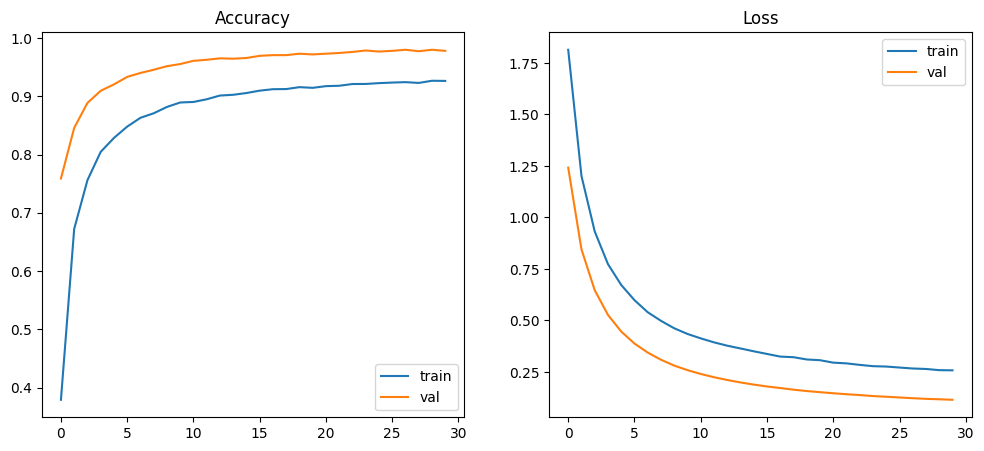

In [4]:
# ===============================
# 7. Plot Accuracy & Loss
# ===============================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.show()

In [5]:

# ===============================
# 8. Evaluation on Test Set
# ===============================
y_true, y_pred = [], []
for batch_images, batch_labels in test_ds:
    preds = model.predict(batch_images)
    preds_classes = np.argmax(preds, axis=1)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(preds_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━

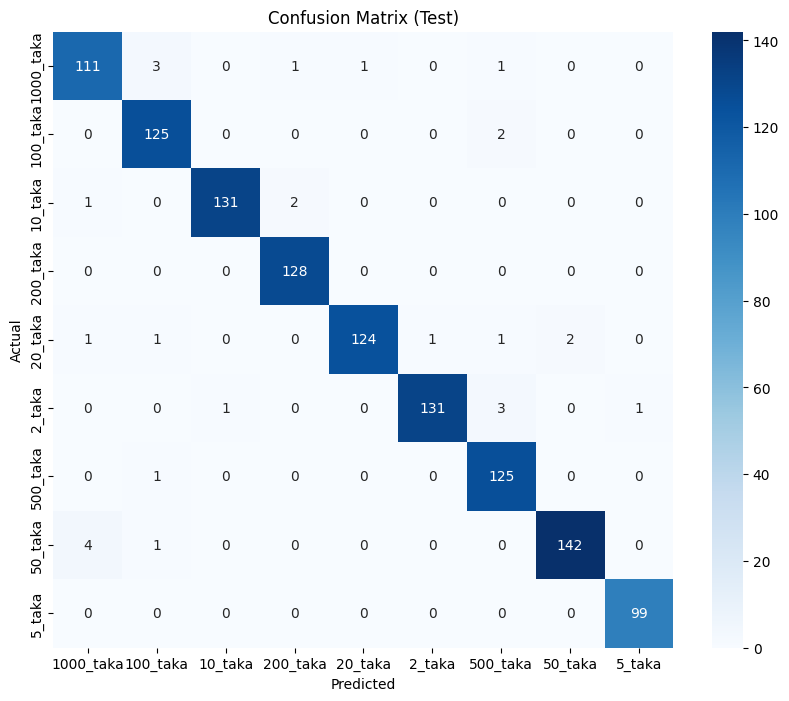

In [6]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test)')
plt.show()

In [7]:
# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

   1000_taka       0.95      0.95      0.95       117
    100_taka       0.95      0.98      0.97       127
     10_taka       0.99      0.98      0.98       134
    200_taka       0.98      1.00      0.99       128
     20_taka       0.99      0.95      0.97       130
      2_taka       0.99      0.96      0.98       136
    500_taka       0.95      0.99      0.97       126
     50_taka       0.99      0.97      0.98       147
      5_taka       0.99      1.00      0.99        99

    accuracy                           0.98      1144
   macro avg       0.98      0.98      0.98      1144
weighted avg       0.98      0.98      0.98      1144

